# **CASE STUDY PROJECT - LOAN APPROVAL PREDICTION**

# **Data Exploration**

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc




df = pd.read_excel('Cleaned_Loan_Data_2.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    object 
 2   Gender_code              614 non-null    int64  
 3   Married                  614 non-null    object 
 4   Married_code             614 non-null    int64  
 5   Dependents               614 non-null    int64  
 6   Education                614 non-null    object 
 7   Graduate_code            614 non-null    int64  
 8   Self_Employed            614 non-null    object 
 9   Self_Employed_code       614 non-null    int64  
 10  ApplicantIncome          614 non-null    int64  
 11  CoapplicantIncome        614 non-null    float64
 12  LoanAmount               614 non-null    int64  
 13  Loan_Amount_Term         614 non-null    int64  
 14  Credit_History           6

In [28]:
# Check for missing values
missing = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing,'Missing %': missing_percentage})
print(missing_df)

                         Missing Values  Missing %
Loan_ID                               0        0.0
Gender                                0        0.0
Gender_code                           0        0.0
Married                               0        0.0
Married_code                          0        0.0
Dependents                            0        0.0
Education                             0        0.0
Graduate_code                         0        0.0
Self_Employed                         0        0.0
Self_Employed_code                    0        0.0
ApplicantIncome                       0        0.0
CoapplicantIncome                     0        0.0
LoanAmount                            0        0.0
Loan_Amount_Term                      0        0.0
Credit_History                        0        0.0
Property_Area                         0        0.0
Property_urban_code                   0        0.0
Property_semiurban_code               0        0.0
Property_rural_code            

In [29]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
# Statistics of the dataset
print(df.describe())
print(df.select_dtypes(include='object').describe())


Number of duplicate rows: 0
       Gender_code  Married_code  Dependents  Graduate_code  \
count   614.000000    614.000000  614.000000     614.000000   
mean      0.817590      0.653094    0.744300       0.781759   
std       0.386497      0.476373    1.009623       0.413389   
min       0.000000      0.000000    0.000000       0.000000   
25%       1.000000      0.000000    0.000000       1.000000   
50%       1.000000      1.000000    0.000000       1.000000   
75%       1.000000      1.000000    1.000000       1.000000   
max       1.000000      1.000000    3.000000       1.000000   

       Self_Employed_code  ApplicantIncome  CoapplicantIncome     LoanAmount  \
count          614.000000       614.000000         614.000000     614.000000   
mean             0.133550      5403.459283        1621.245798  145752.442997   
std              0.340446      6109.041673        2926.248369   84107.233380   
min              0.000000       150.000000           0.000000    9000.000000   
25% 

# **Visualizations**

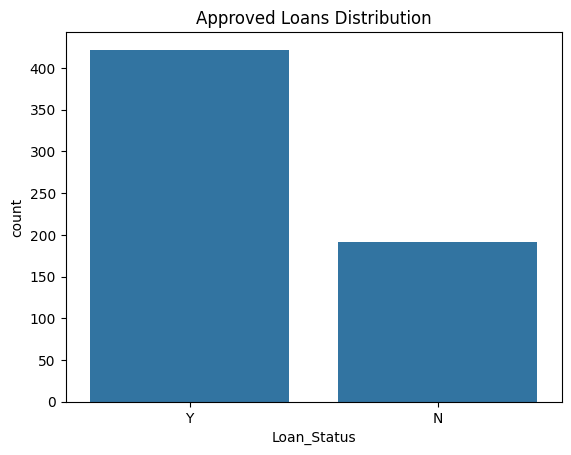

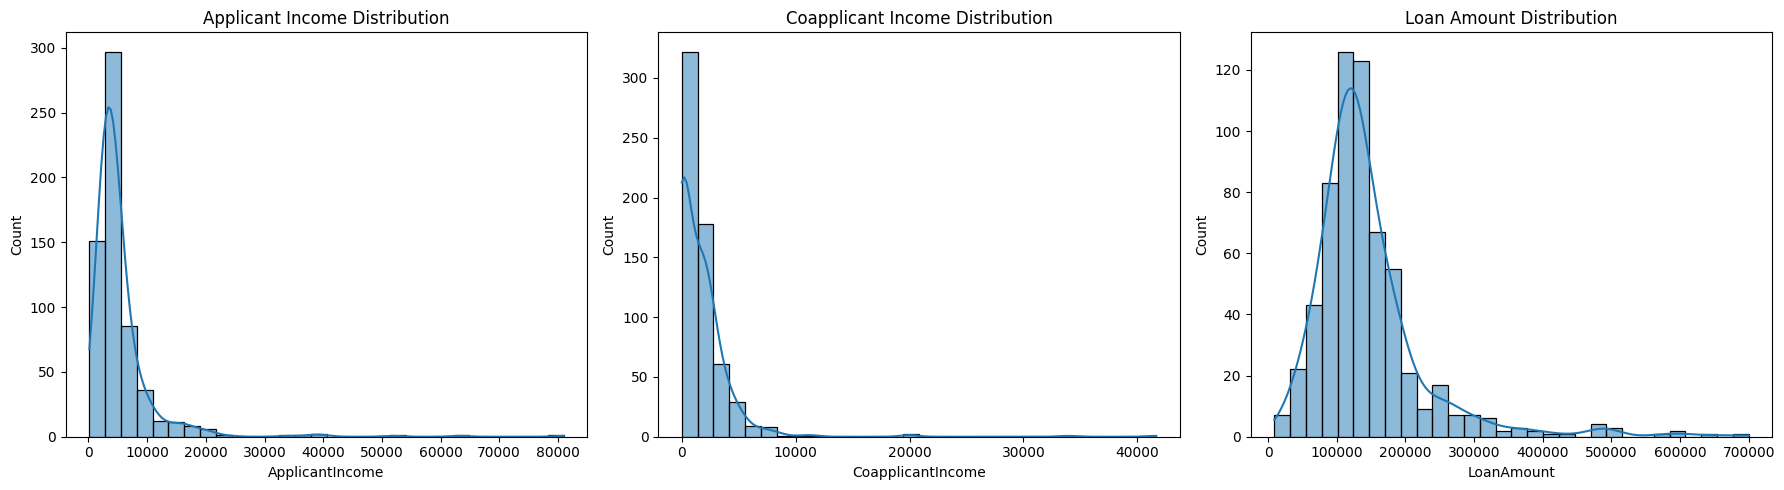

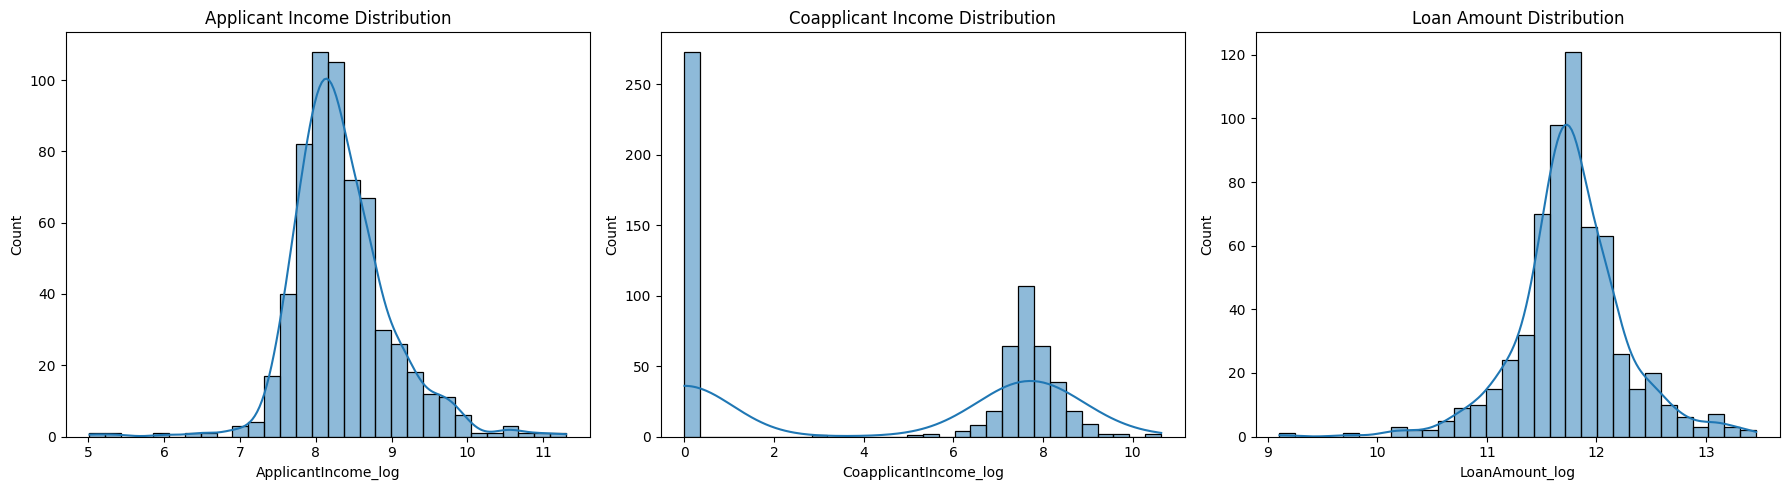

In [30]:
sns.countplot(data=df, x='Loan_Status')
plt.title("Approved Loans Distribution")
plt.show()

# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['ApplicantIncome'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Applicant Income Distribution")

sns.histplot(df['CoapplicantIncome'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Coapplicant Income Distribution")

sns.histplot(df['LoanAmount'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Loan Amount Distribution")

plt.tight_layout()
plt.show()

# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['ApplicantIncome_log'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Applicant Income Distribution")

sns.histplot(df['CoapplicantIncome_log'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Coapplicant Income Distribution")

sns.histplot(df['LoanAmount_log'], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Loan Amount Distribution")

plt.tight_layout()
plt.show()

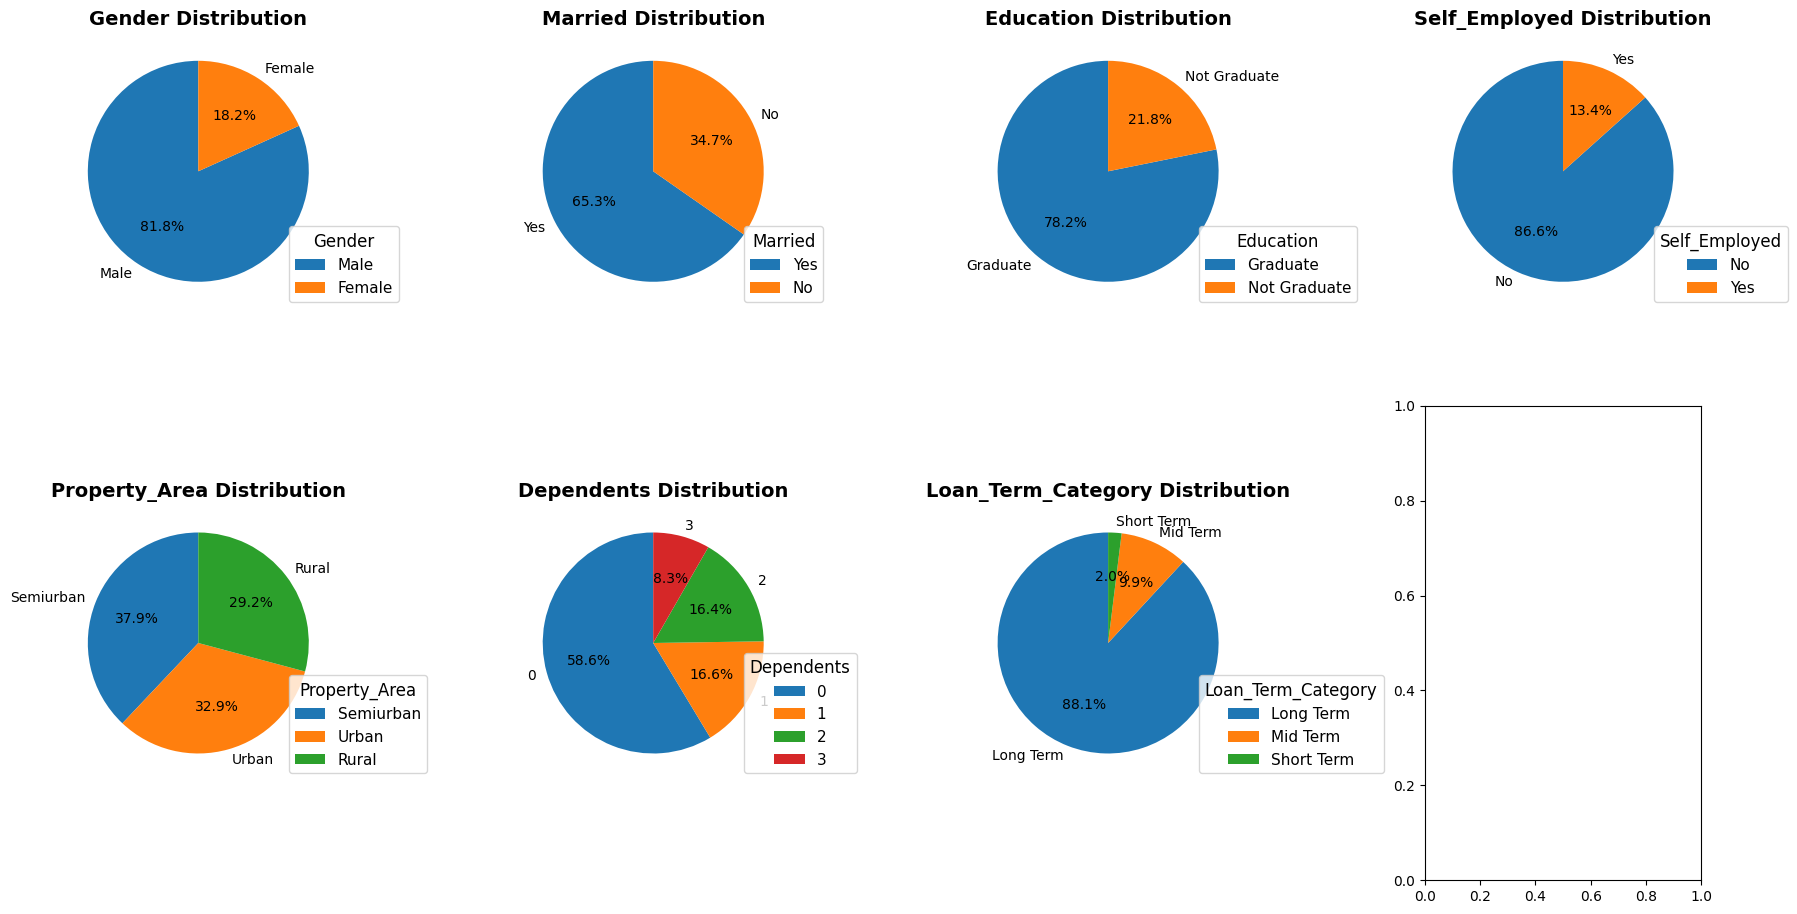

In [ ]:
categorical = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents', 'Loan_Term_Category']

## Pie charts
fig, axes = plt.subplots(2, 4, figsize=(18, 10)) 

for i, col in enumerate(categorical):

    counts = df[col].value_counts(dropna=False)
    labels = counts.index.astype(str)
    sizes = counts.values
    ax = axes[i // 4, i % 4]
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{col} Distribution', fontsize=14, fontweight='bold')
    ax.legend(wedges, labels, title=col, loc='lower left', bbox_to_anchor=(0.8, 0.0), fontsize=11, title_fontsize=12)

    
plt.tight_layout()
plt.show()


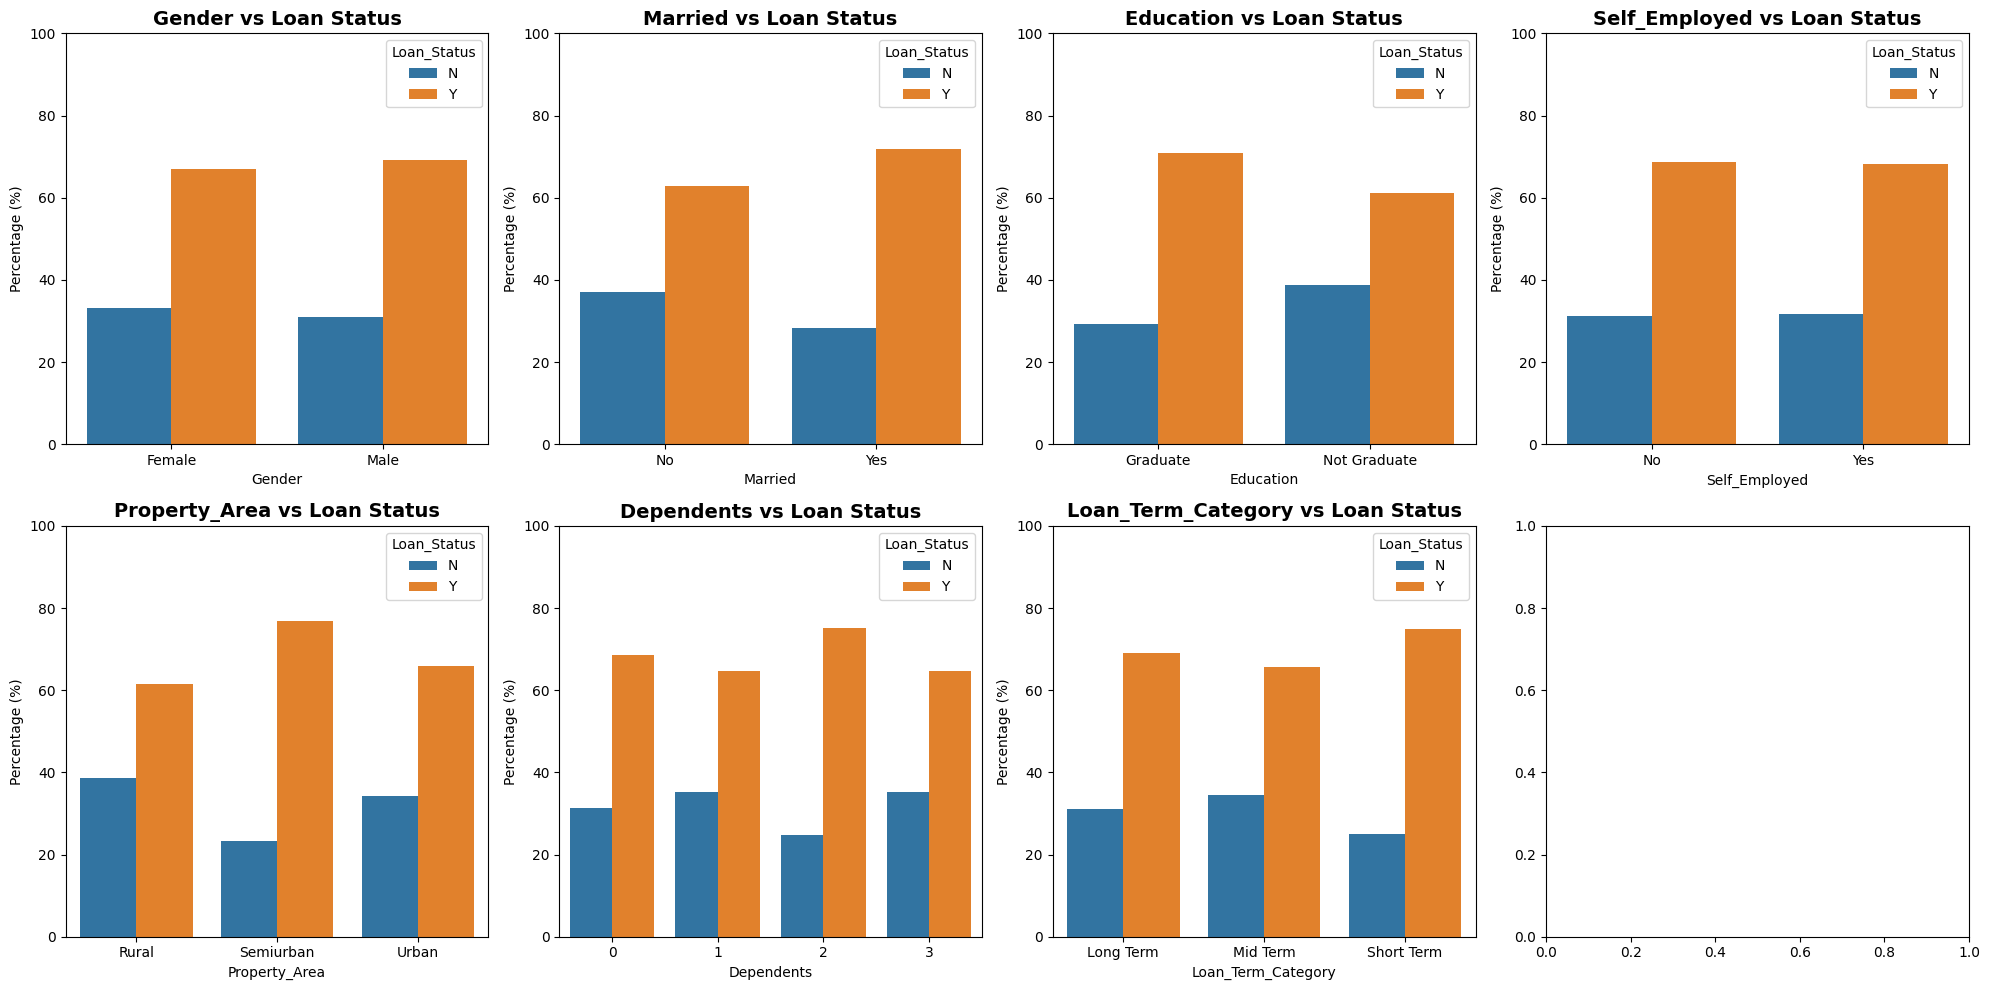

In [ ]:

# Bar plots for categorical variables vs Loan_Status

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(categorical):
    ax = axes[i // 4, i % 4]
    count_df = df.groupby([col, 'Loan_Status']).size().reset_index(name='Count')
    total_df = df.groupby([col]).size().reset_index(name='Total')
    merged_df = pd.merge(count_df, total_df, on=col)
    merged_df['Percentage'] = 100 * merged_df['Count'] / merged_df['Total']
    
    sns.barplot(data=merged_df, x=col, y='Percentage', hue='Loan_Status', ax=ax)
    ax.set_title(f"{col} vs Loan Status", fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel(col)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


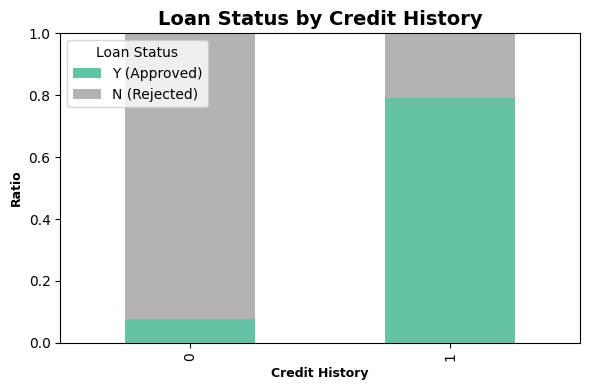

In [34]:
credit_ratio = pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index')
credit_ratio = credit_ratio[['Y', 'N']]
credit_ratio.plot(kind='bar', stacked=True, colormap='Set2', figsize=(6,4))

plt.title('Loan Status by Credit History',fontsize=14, fontweight='bold')
plt.xlabel('Credit History',fontsize=9, fontweight='bold')
plt.ylabel('Ratio',fontsize=9, fontweight='bold')
plt.ylim(0, 1)
plt.legend(title='Loan Status', labels=['Y (Approved)', 'N (Rejected)'])
plt.tight_layout()
plt.show()

Loan_Status_code         1.000000
CoapplicantIncome_log    0.060593
ApplicantIncome_log      0.010959
Dependents               0.010118
Loan_Amount_Term        -0.022549
LoanAmount_log          -0.037997
Name: Loan_Status_code, dtype: float64


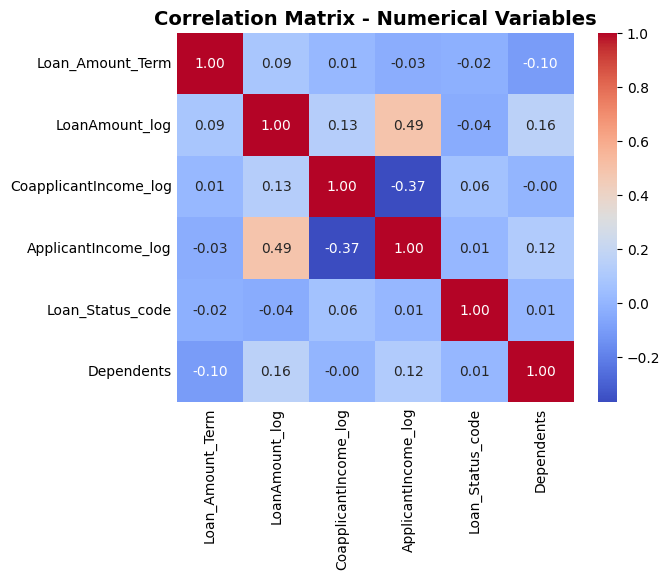

In [39]:
# Selección correcta de columnas
cols = ['Loan_Amount_Term', 'LoanAmount_log', 'CoapplicantIncome_log', 'ApplicantIncome_log', 'Loan_Status_code','Dependents']

# Calcular correlación
corr_numeric = df[cols].corr()['Loan_Status_code'].sort_values(ascending=False)
print(corr_numeric)

# Heatmap solo para las columnas seleccionadas
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)

plt.title("Correlation Matrix - Numerical Variables",fontsize=14, fontweight='bold')
plt.tick_params(axis='x', which='both', length=0)
plt.tick_params(axis='y', which='both', length=0) 
plt.show()


Loan_Status_code           1.000000
Credit_History             0.540556
Property_semiurban_code    0.136540
Married_code               0.091478
Graduate_code              0.085884
Gender_code                0.017987
Self_Employed_code        -0.003700
Property_urban_code       -0.043621
Property_rural_code       -0.100694
Name: Loan_Status_code, dtype: float64


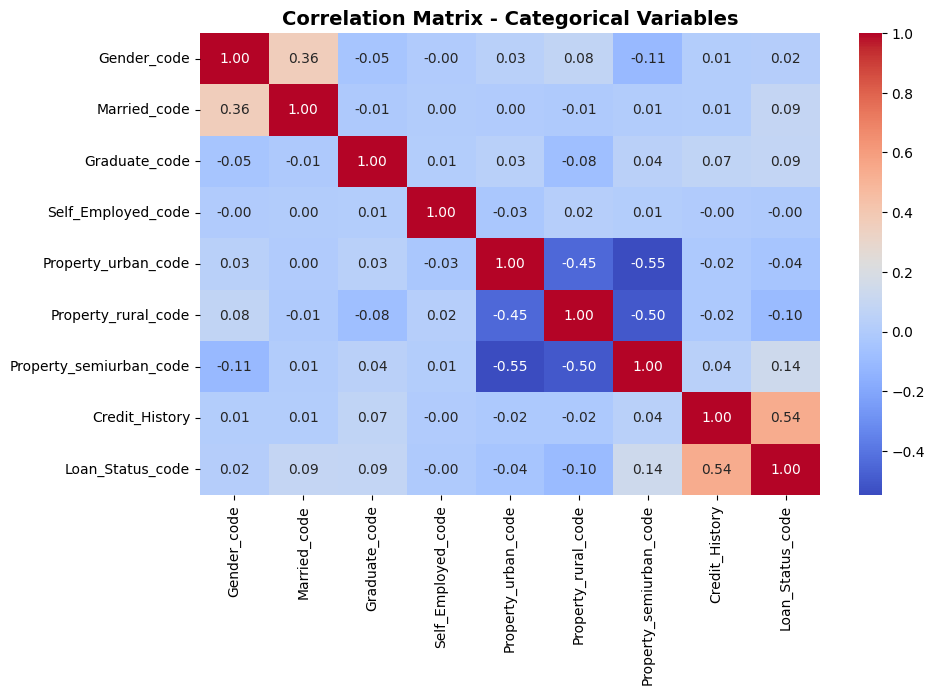

In [42]:
# Seleccionar columnas dummy (puedes filtrar por nombre si terminan en '_code')
categorical_dummies = ['Gender_code','Married_code','Graduate_code','Self_Employed_code','Property_urban_code','Property_rural_code','Property_semiurban_code','Credit_History']

# Crear DataFrame para correlación
df_cat_corr = df[categorical_dummies + ['Loan_Status_code']]

# Calcular correlación
corr_categorical = df_cat_corr.corr()['Loan_Status_code'].sort_values(ascending=False)
print(corr_categorical)

# Graficar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_cat_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix - Categorical Variables",fontsize=14, fontweight='bold')
plt.show()

# **Logistic Regression Model**

Accuracy: 0.7837837837837838
Confusion Matrix:
 [[ 27  38]
 [  2 118]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185



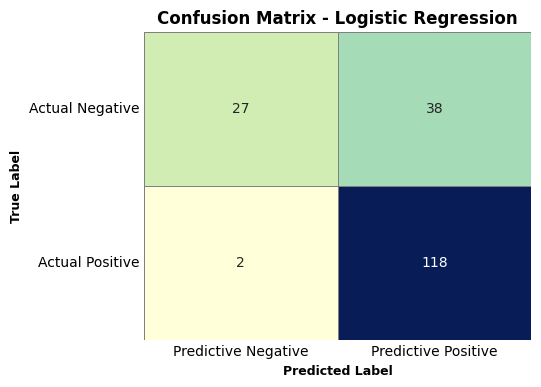


 Most important variables:
Credit_History             3.208564
Married_code               0.621867
Property_semiurban_code    0.577044
Graduate_code              0.216205
ApplicantIncome_log        0.059990
Gender_code               -0.156077
LoanAmount_log            -0.195168
Property_urban_code       -0.248360
Property_rural_code       -0.329420
dtype: float64


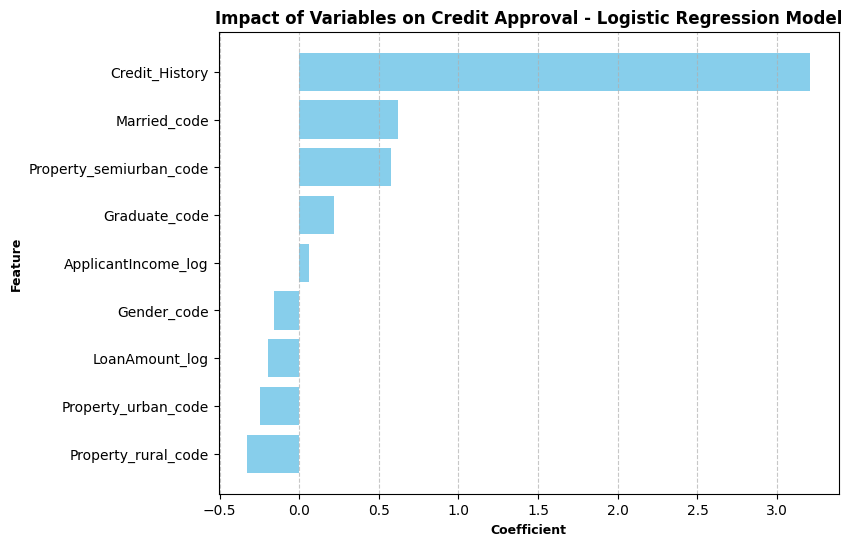

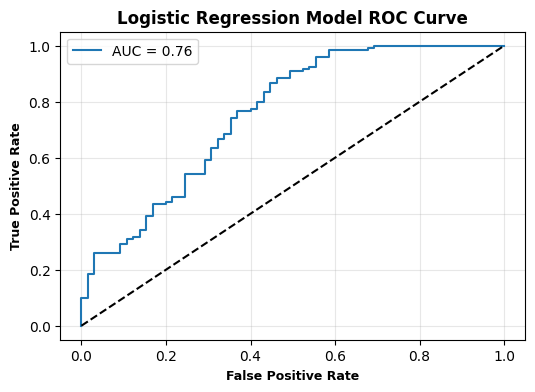

In [70]:
from sklearn.linear_model import LogisticRegression

X = df[['Gender_code','Married_code','Graduate_code',
        'Property_semiurban_code','Property_urban_code','Property_rural_code',
        'Credit_History','LoanAmount_log',
        'ApplicantIncome_log',]]
y = df['Loan_Status_code']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]  

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

#confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False,linewidths=0.7, linecolor='gray')
plt.title(f'Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=9, fontweight='bold')
plt.ylabel('True Label', fontsize=9, fontweight='bold')
plt.tick_params(axis='x', which='both', length=0)
plt.tick_params(axis='y', which='both', length=0)
plt.xticks(ticks=[0.5,1.5], labels=['Predictive Negative','Predictive Positive'], rotation=0)
plt.yticks(ticks=[0.5,1.5], labels=['Actual Negative','Actual Positive'], rotation=0)
plt.show()

# Most important variables
importance = model.coef_[0]
feature_importance = pd.Series(importance, index=X.columns).sort_values(ascending=False)
print("\n Most important variables:")
print(feature_importance)

# Bar plot
plt.figure(figsize=(8,6))
plt.barh(feature_importance.index, feature_importance.values, color='skyblue')  # color sólido
plt.xlabel('Coefficient',fontsize=9, fontweight='bold')
plt.ylabel('Feature',fontsize=9, fontweight='bold')
plt.title('Impact of Variables on Credit Approval - Logistic Regression Model',fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)  # grid solo en eje X
plt.gca().invert_yaxis()
plt.show()

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'Logistic Regression Model ROC Curve',fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate',fontsize=9, fontweight='bold')
plt.ylabel('True Positive Rate',fontsize=9, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.show()




# **Random Forest and Xgboost Models**


--- Random Forest ---
Accuracy: 0.7621621621621621
Confusion Matrix:
 [[ 32  33]
 [ 11 109]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.49      0.59        65
           1       0.77      0.91      0.83       120

    accuracy                           0.76       185
   macro avg       0.76      0.70      0.71       185
weighted avg       0.76      0.76      0.75       185



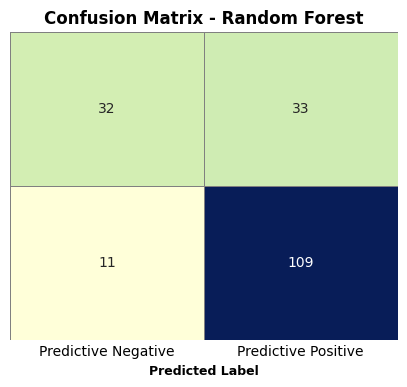

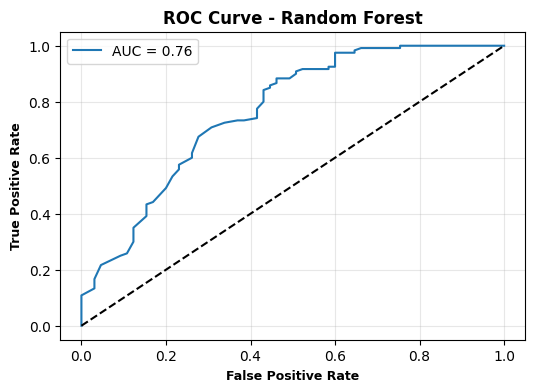

Most important variables:
Credit_History             0.253285
ApplicantIncome_log        0.221378
LoanAmount_log             0.206200
CoapplicantIncome_log      0.123478
Dependents                 0.052327
Married_code               0.030205
Property_semiurban_code    0.027011
Graduate_code              0.025442
Gender_code                0.025146
Property_rural_code        0.019016
Property_urban_code        0.016515
dtype: float64


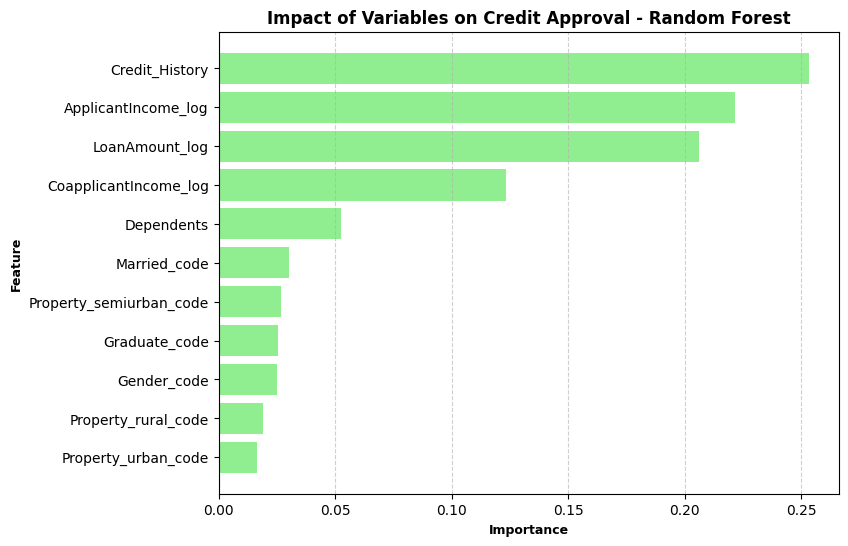


--- XGBoost ---
Accuracy: 0.7405405405405405
Confusion Matrix:
 [[ 31  34]
 [ 14 106]]
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.48      0.56        65
           1       0.76      0.88      0.82       120

    accuracy                           0.74       185
   macro avg       0.72      0.68      0.69       185
weighted avg       0.73      0.74      0.73       185



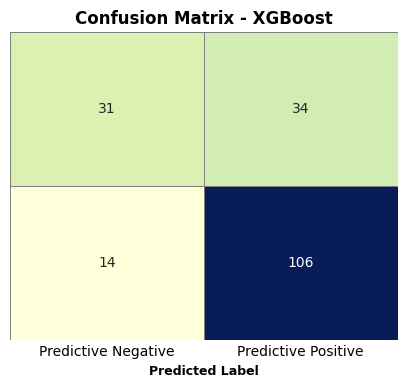

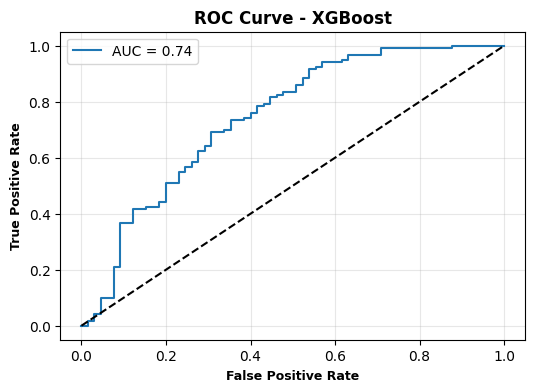

Most important variables:
Credit_History             0.529065
Property_semiurban_code    0.091586
LoanAmount_log             0.048808
ApplicantIncome_log        0.048255
CoapplicantIncome_log      0.047683
Property_urban_code        0.042452
Married_code               0.042219
Dependents                 0.042172
Gender_code                0.041687
Graduate_code              0.033552
Property_rural_code        0.032521
dtype: float32


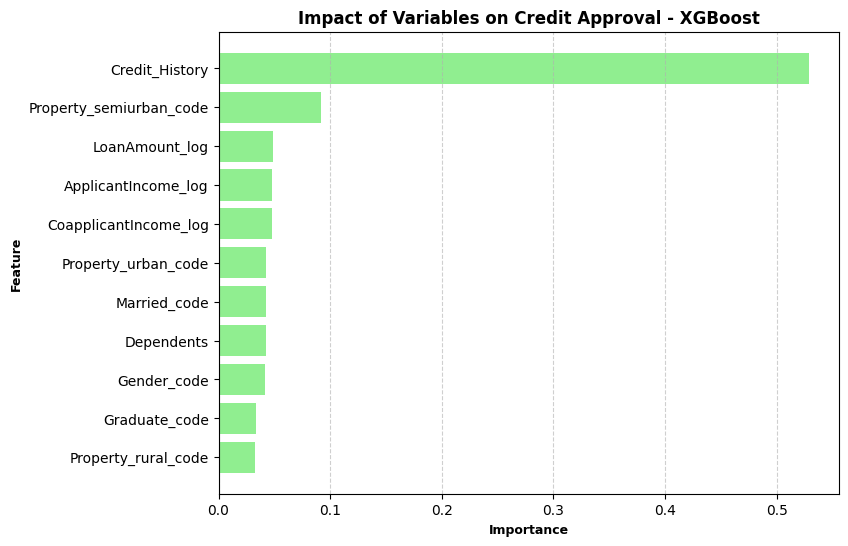

In [69]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Variables
X = df[['Gender_code','Credit_History','Property_semiurban_code','Property_urban_code','Property_rural_code',
        'Married_code','Graduate_code','LoanAmount_log','CoapplicantIncome_log',
        'ApplicantIncome_log','Dependents']]
y = df['Loan_Status_code']

# train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    print(f"\n--- {name} ---")
    
    # training and prediction
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]  # Probabilidad clase 1
    
    # Evaluation
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    #confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False,linewidths=0.7, linecolor='gray')
    plt.title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=9, fontweight='bold')
    plt.tick_params(axis='x', which='both', length=0)
    plt.tick_params(axis='y', which='both', length=0)
    plt.xticks(ticks=[0.5,1.5], labels=['Predictive Negative','Predictive Positive'], rotation=0)
    plt.yticks([])
    plt.show()
    
    # ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - {name}', fontsize=12, fontweight='bold')
    plt.xlabel('False Positive Rate', fontsize=9, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=9, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    # Most important variables
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("Most important variables:")
    print(importance)
    
    #importance plot
    plt.figure(figsize=(8,6))
    plt.barh(importance.index, importance.values, color='lightgreen')
    plt.xlabel('Importance', fontsize=9, fontweight='bold')
    plt.ylabel('Feature', fontsize=9, fontweight='bold')
    plt.title(f'Impact of Variables on Credit Approval - {name}', fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()
